### Introduction to Support Vector Machines

$\text{Support Vector Machines}$ are Machine Learning algorithms that are used for classification and regression purposes. SVMs are one of the powerful machine learning algorithms for classification, regression and outlier detection purposes. An SVM classifier builds a model that assigns new data points to one of the given categories. Thus, it can be viewed as a non-probabilistic binary linear classifier.

$\text{SVMs}$ can be used for linear classification purposes. In addition to performing linear classification. $\text{SVMs}$ can efficiently perform a non-linear classification using the $\text{kernel trick}$. It enable us to implicity map the inputs into high dimentional feature spaces.

### Support Vector Machines intuition

1. $\text{Hyperplane}$

A $\text{hyperplane}$ is a decision boundary which separates between the given set of data points having different class labels. The $SVM$ classifier separates data points using a hyperplane with the maximum amount of margin. This hyperplane is known as the $\text{maximum margin hyperplane}$ and the linear classifier it defines is known as the $\text{maximum margin classifier}$. 

2. $\text{Support Vectors}$

$\text{Support vectors}$ are the sample data points, which are closest to the hyperplane. These data points will define the separating line or hyperplane better by calculation margins.

3. $\text{Margin}$

A $\text{Margin}$ is a separation gap between the two lines on the closest data points. It is calculated as the perpendicular distance from the line to support vectors or closet data points. In $\text{SVMs}$, we try to maximize this separation gap so that we get maximum margin.

4. $\text{SVM Under the hood}$

In $\text{SVMs}$, our main objective is to select a hyperplane with the maximum possible margin between support vectors in the given dataset. $\text{SVM}$ searches for the maximum margin hyperplane in the following 2 steps:

    4.1 Generate hyperplanes which segregates the classes in the best possible way. There are many hyperplanes that might classify the data. We should look for the best hyperplane that represents the largest separation, or margin, between the two classes.
    4.2 So, we choose the hyperplane so that distance from it to the support vectors on each side is maximized. If such a hyperplane exists, it is known as the maximum margin hyperplane and the linear classifier it defines is known as a maximum margin classifier.
    
5. Problem with dispersed datasets.

Sometimes, the sample data points are so dispersed that it is not possible to separate them using a $\text{linear hyperplane}$. In such a situation, SVMs uses a $\text{kernel trick}$ to transform the input space to a higher dimension space. It uses a $\text{mapping function}$ to transform the 2-D input space into the 3-D input space. Now, we can easily segregate the data points using linear separation. 

### Kernel trick

In practice, $\text{SVM algorithm}$ is implemented using a $\text{Kernel}$. It uses a technique called the $\text{Kernel trick}$. In simple words, a $\text{Kernel}$ is just a function that maps the data to a higher dimension where data is separable. A $\text{kernel}$ transforms a low-dimensional input data space into a higher dimensional space. So, it converts non-linear separable problems to linear separable problems by adding more dimensions to it. Thus, the $\text{kernel trick}$ help us to build a more accurate classifier. Hence, it is useful in non-linear separation problems.

We can define a kernel function as follows:

Kernel function
$$K(\overline{x}) =
    \begin{cases}
    1 & \text{if } \|\overline{x}\| \leq1 \\
    0 & \text{if } \|\overline{x}\| \text{ otherwise}
    \end{cases}$$ 

In the context of $\text{SVMs}$, there are 4 popular kernels - $\text{Linear kernel}$, $\text{Polynomial kernel}$, $\text{Radial Basis Function (RBF) kernel}$ (also called $\text{Gaussian kernel}$) and $\text{Sigmoid kernel}$.  

#### Linear kernel

In $\text{linear kernel}$, the $\text{kernel function}$ takes the form of a linear function as follows: 
$$\text{Linear kernel: } K(x_{i}, x_{j}) = (x_{i})^{T}x_{j}$$

Linear kernel is used when the data is linearly separable. It means that data can be separated using a single line. It is one of the most common kernels to be used. It is mostly used when there are large number of features in a dataset. Linear kernel is often used for text classification purposes.

Training with a linear kernel is usually faster, because we only need to optimize the $\text{C regularization}$ parameter. When training with other kernels, we also need to optimize the $y$ parameter. So, performing a grid search will usually take more time.

#### Polynomial Kernel

Polynomial kernel represents the similarity of vectors (training samples) in a feature space over polynomials of the original variables. The polynomial kernel looks not only at the given features of input samples to determine their similarity, but also combinations of the input samples.

For $d$-degree polynomials, the polynomial kernel is defined as follows:

$$\text{Polynomial kernel}: K(x_{i}, x_{j}) = (y(x_{i})^{T}x_{j}+r)^{d}, \text{with }y>0$$

$\text{Polynomial kernel}$ is very popular in Natural Language Processing. The most common degree is d = 2 (quadratic), since larger degrees tend to overfit on NLP problems.

#### Radial Basis Function Kernel

$\text{Radial basis function kernel}$ is a general purpose kernel. It is used when we have no prior knowledge about the data. The $\text{RBF kernel}$ on two samples $x$ and $y$ is defined by the following equation:

$$\text{Radial Basis Function kernel}: k(x,y) = exp(-\frac{\|x-y\|^{2}}{2\sigma^{2}})$$

#### Sigmoid Kernel

$\text{Sigmoid kernel}$ has its origin in neural networks. We can use it as the proxy for neural networks. Sigmoid kernel is given by the following equation:

$$\text{Sigmoid Kernel}: K(x,y) = tanh(\alpha x^{T}y + c)$$

In [83]:
#Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("C:/Users/ADMIN/OneDrive/Desktop/Ok/ML/Support Vector Machines/pulsar_data_train.csv")
df.shape

(12528, 9)

In [85]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


We can see that there are 9 variables in the dataset. 8 are continuous variables and 1 is discrete variable. The discrete variable is $\text{target class}$ variable, and it is also our target variable

In [86]:
df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [87]:
#Removing the space in the head of columns' names
df.columns = df.columns.str.strip()
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [88]:
#Check distribution of target_class column

df["target_class"].value_counts()

target_class
0.0    11375
1.0     1153
Name: count, dtype: int64

In [89]:
#The percentage distribution of target_class column

df["target_class"].value_counts()/len(df["target_class"])

target_class
0.0    0.907966
1.0    0.092034
Name: count, dtype: float64

In [90]:
#view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12528 entries, 0 to 12527
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Mean of the integrated profile                12528 non-null  float64
 1   Standard deviation of the integrated profile  12528 non-null  float64
 2   Excess kurtosis of the integrated profile     10793 non-null  float64
 3   Skewness of the integrated profile            12528 non-null  float64
 4   Mean of the DM-SNR curve                      12528 non-null  float64
 5   Standard deviation of the DM-SNR curve        11350 non-null  float64
 6   Excess kurtosis of the DM-SNR curve           12528 non-null  float64
 7   Skewness of the DM-SNR curve                  11903 non-null  float64
 8   target_class                                  12528 non-null  float64
dtypes: float64(9)
memory usage: 881.0 KB


Summary of numerical variables
1. There are 9 numerical variables in the dataset.
2. 8 are continuous variables and 1 is discrete variable.
3. The discrete variable is $\text{target class}$ variable. It is also the target variable.
4. There are a lot of missing values in the dataset.

In [91]:
#process the missing values in the dataset

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy = "mean")
df = imputer.fit_transform(df)

df = pd.DataFrame(df)

In [92]:
#Rename column names

df.columns = ["IP Mean", "IP Sd", "IP Kurtosis", "IP Skewness", "DM-SNR Mean", "DM-SNR Sd", "DM-SNR Kurtosis", "DM-SNR Skewness", "target_class"]
df.columns

Index(['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness', 'DM-SNR Mean',
       'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness', 'target_class'],
      dtype='object')

Text(0, 0.5, 'DM-SNR Skewness')

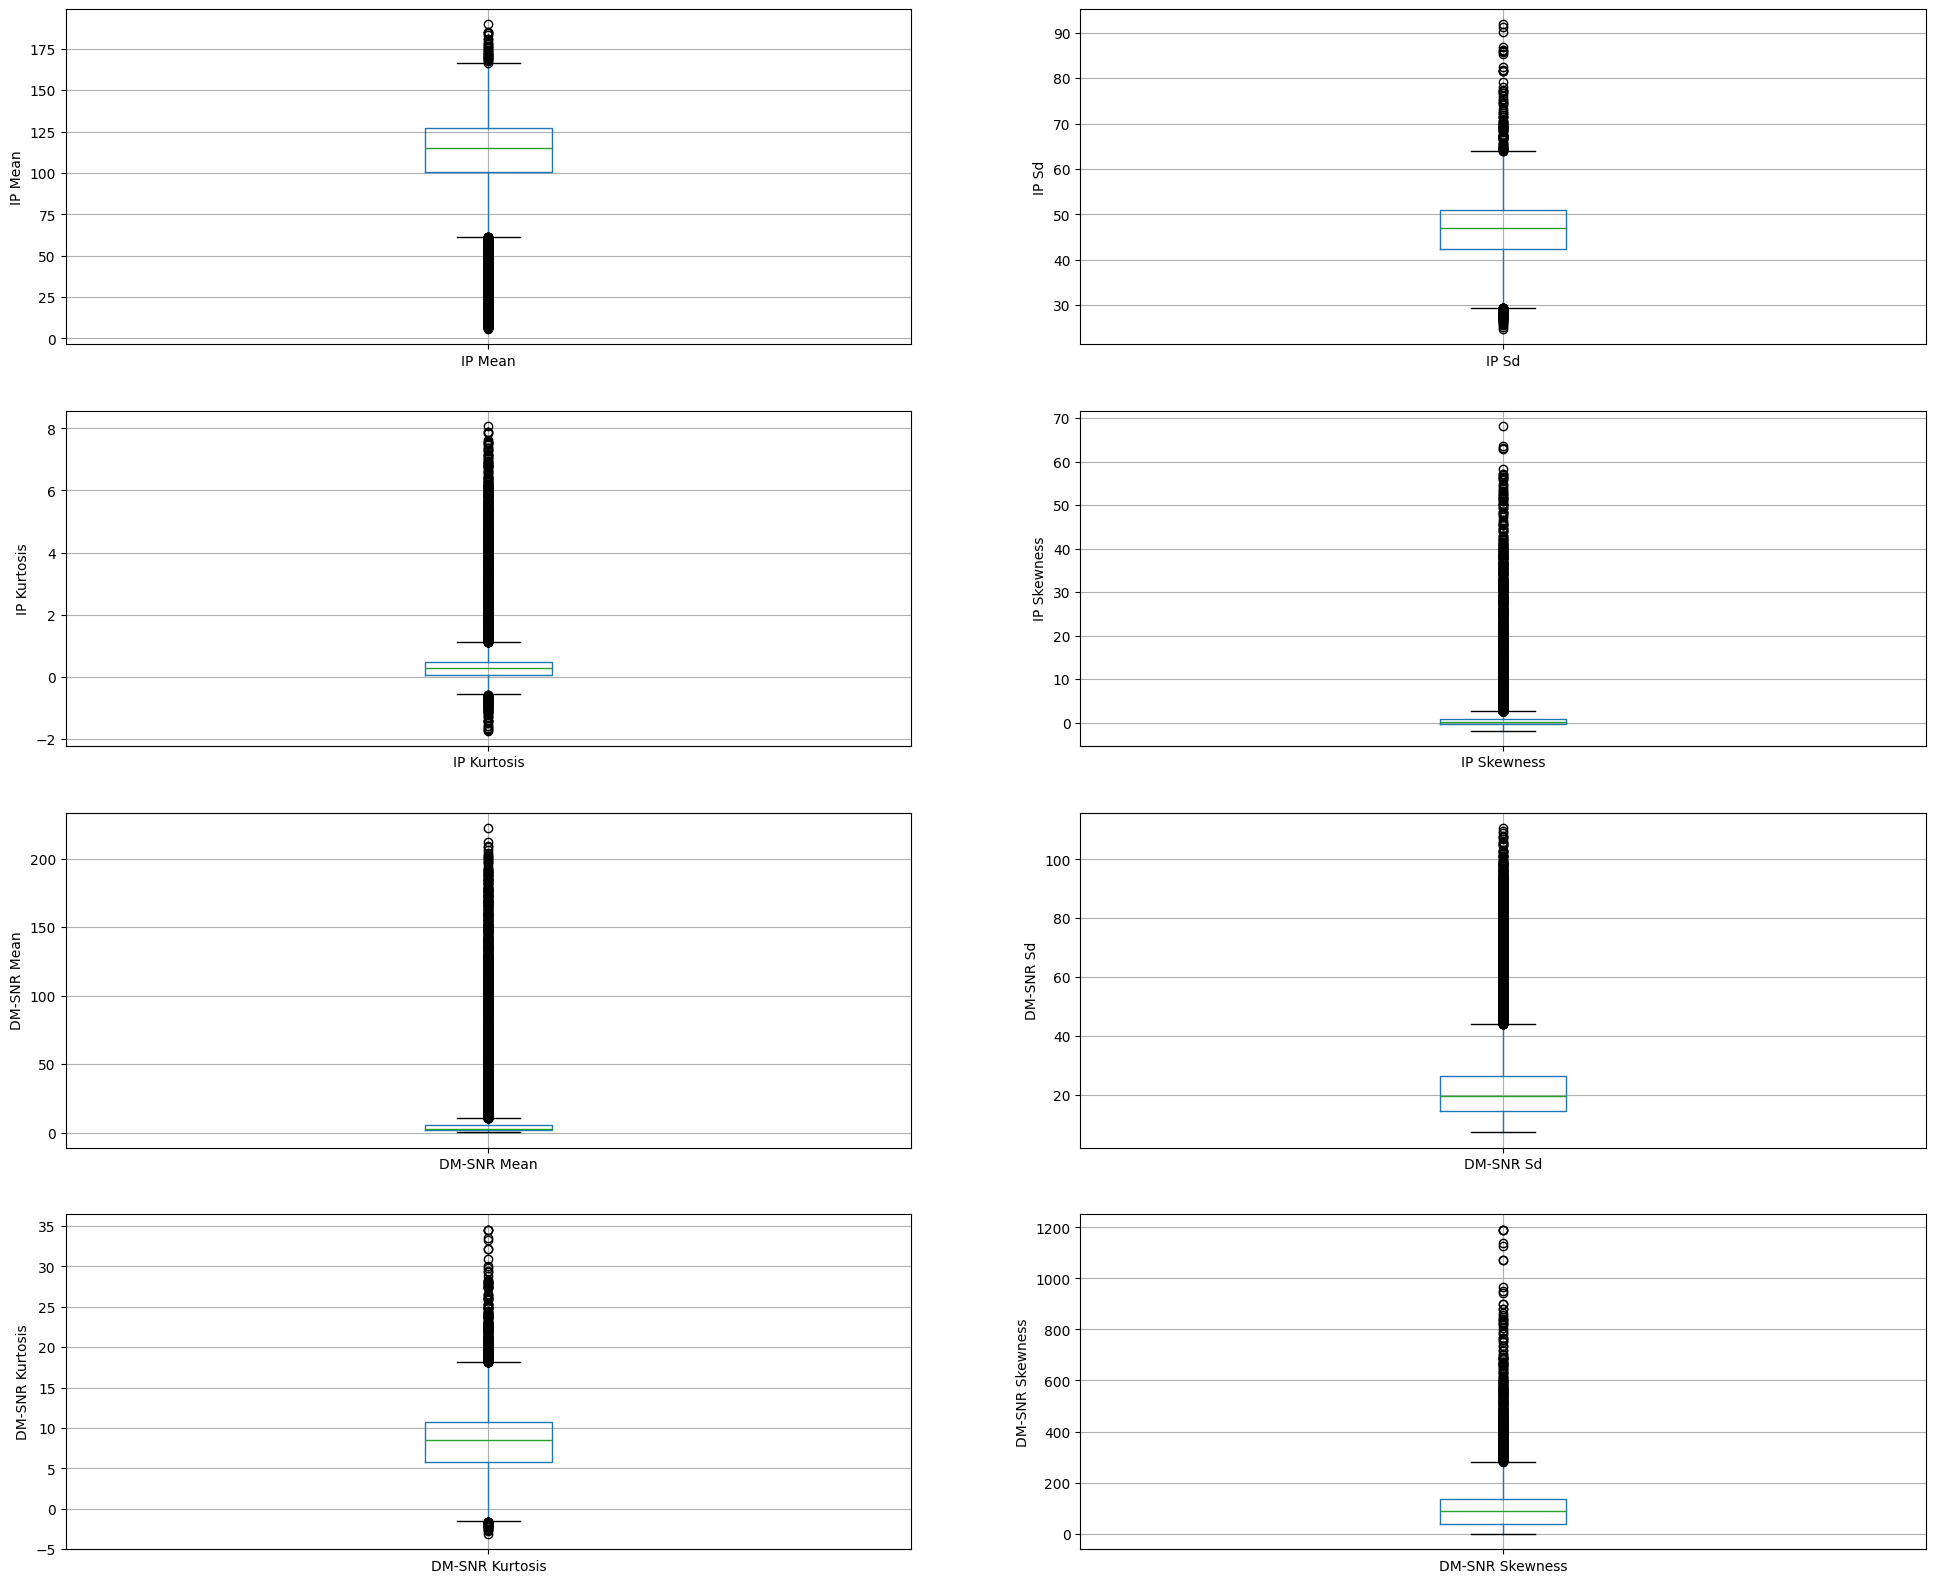

In [93]:
#find the outliers in numerical variables

#round(df.describe(),2)

plt.figure(figsize = (24,20))

plt.subplot(4,2,1)
fig = df.boxplot(column = "IP Mean")
fig.set_title("")
fig.set_ylabel("IP Mean")

plt.subplot(4,2,2)
fig = df.boxplot(column = "IP Sd")
fig.set_title("")
fig.set_ylabel("IP Sd")

plt.subplot(4,2,3)
fig = df.boxplot(column = "IP Kurtosis")
fig.set_title("")
fig.set_ylabel("IP Kurtosis")

plt.subplot(4, 2, 4)
fig = df.boxplot(column='IP Skewness')
fig.set_title('')
fig.set_ylabel('IP Skewness')


plt.subplot(4, 2, 5)
fig = df.boxplot(column='DM-SNR Mean')
fig.set_title('')
fig.set_ylabel('DM-SNR Mean')


plt.subplot(4, 2, 6)
fig = df.boxplot(column='DM-SNR Sd')
fig.set_title('')
fig.set_ylabel('DM-SNR Sd')


plt.subplot(4, 2, 7)
fig = df.boxplot(column='DM-SNR Kurtosis')
fig.set_title('')
fig.set_ylabel('DM-SNR Kurtosis')


plt.subplot(4, 2, 8)
fig = df.boxplot(column='DM-SNR Skewness')
fig.set_title('')
fig.set_ylabel('DM-SNR Skewness')

There are a lot of outliers in these variables.

#### Handle outliers with SVMs

There are 2 variants of SVMS. They are $\text{hard-margin variant of SVM}$ and $\text{soft-margin variant of SVM}$.

The $\text{hard-margin variant of SVM}$ does not deal with outliers. In this case, we want to find the hyperplane with the maximum margin such that every training point is correctly classified with margin at least 1. This technique does not handle outliers well.

Another version of SVM is called $\text{soft-margin variant of SVM}$. In this case, we can have a few points incorrectly classified or classified with a margin less than 1. But for every such point, we have to pay a penalty in form of $\text{C parameter}$, which controls the outliers. Low $C$ implies we are allowing more outliers and high $C$ implies less outliers.

So, the value of $C$ should be low while training the model.

Text(0, 0.5, 'Number of pulsar stars')

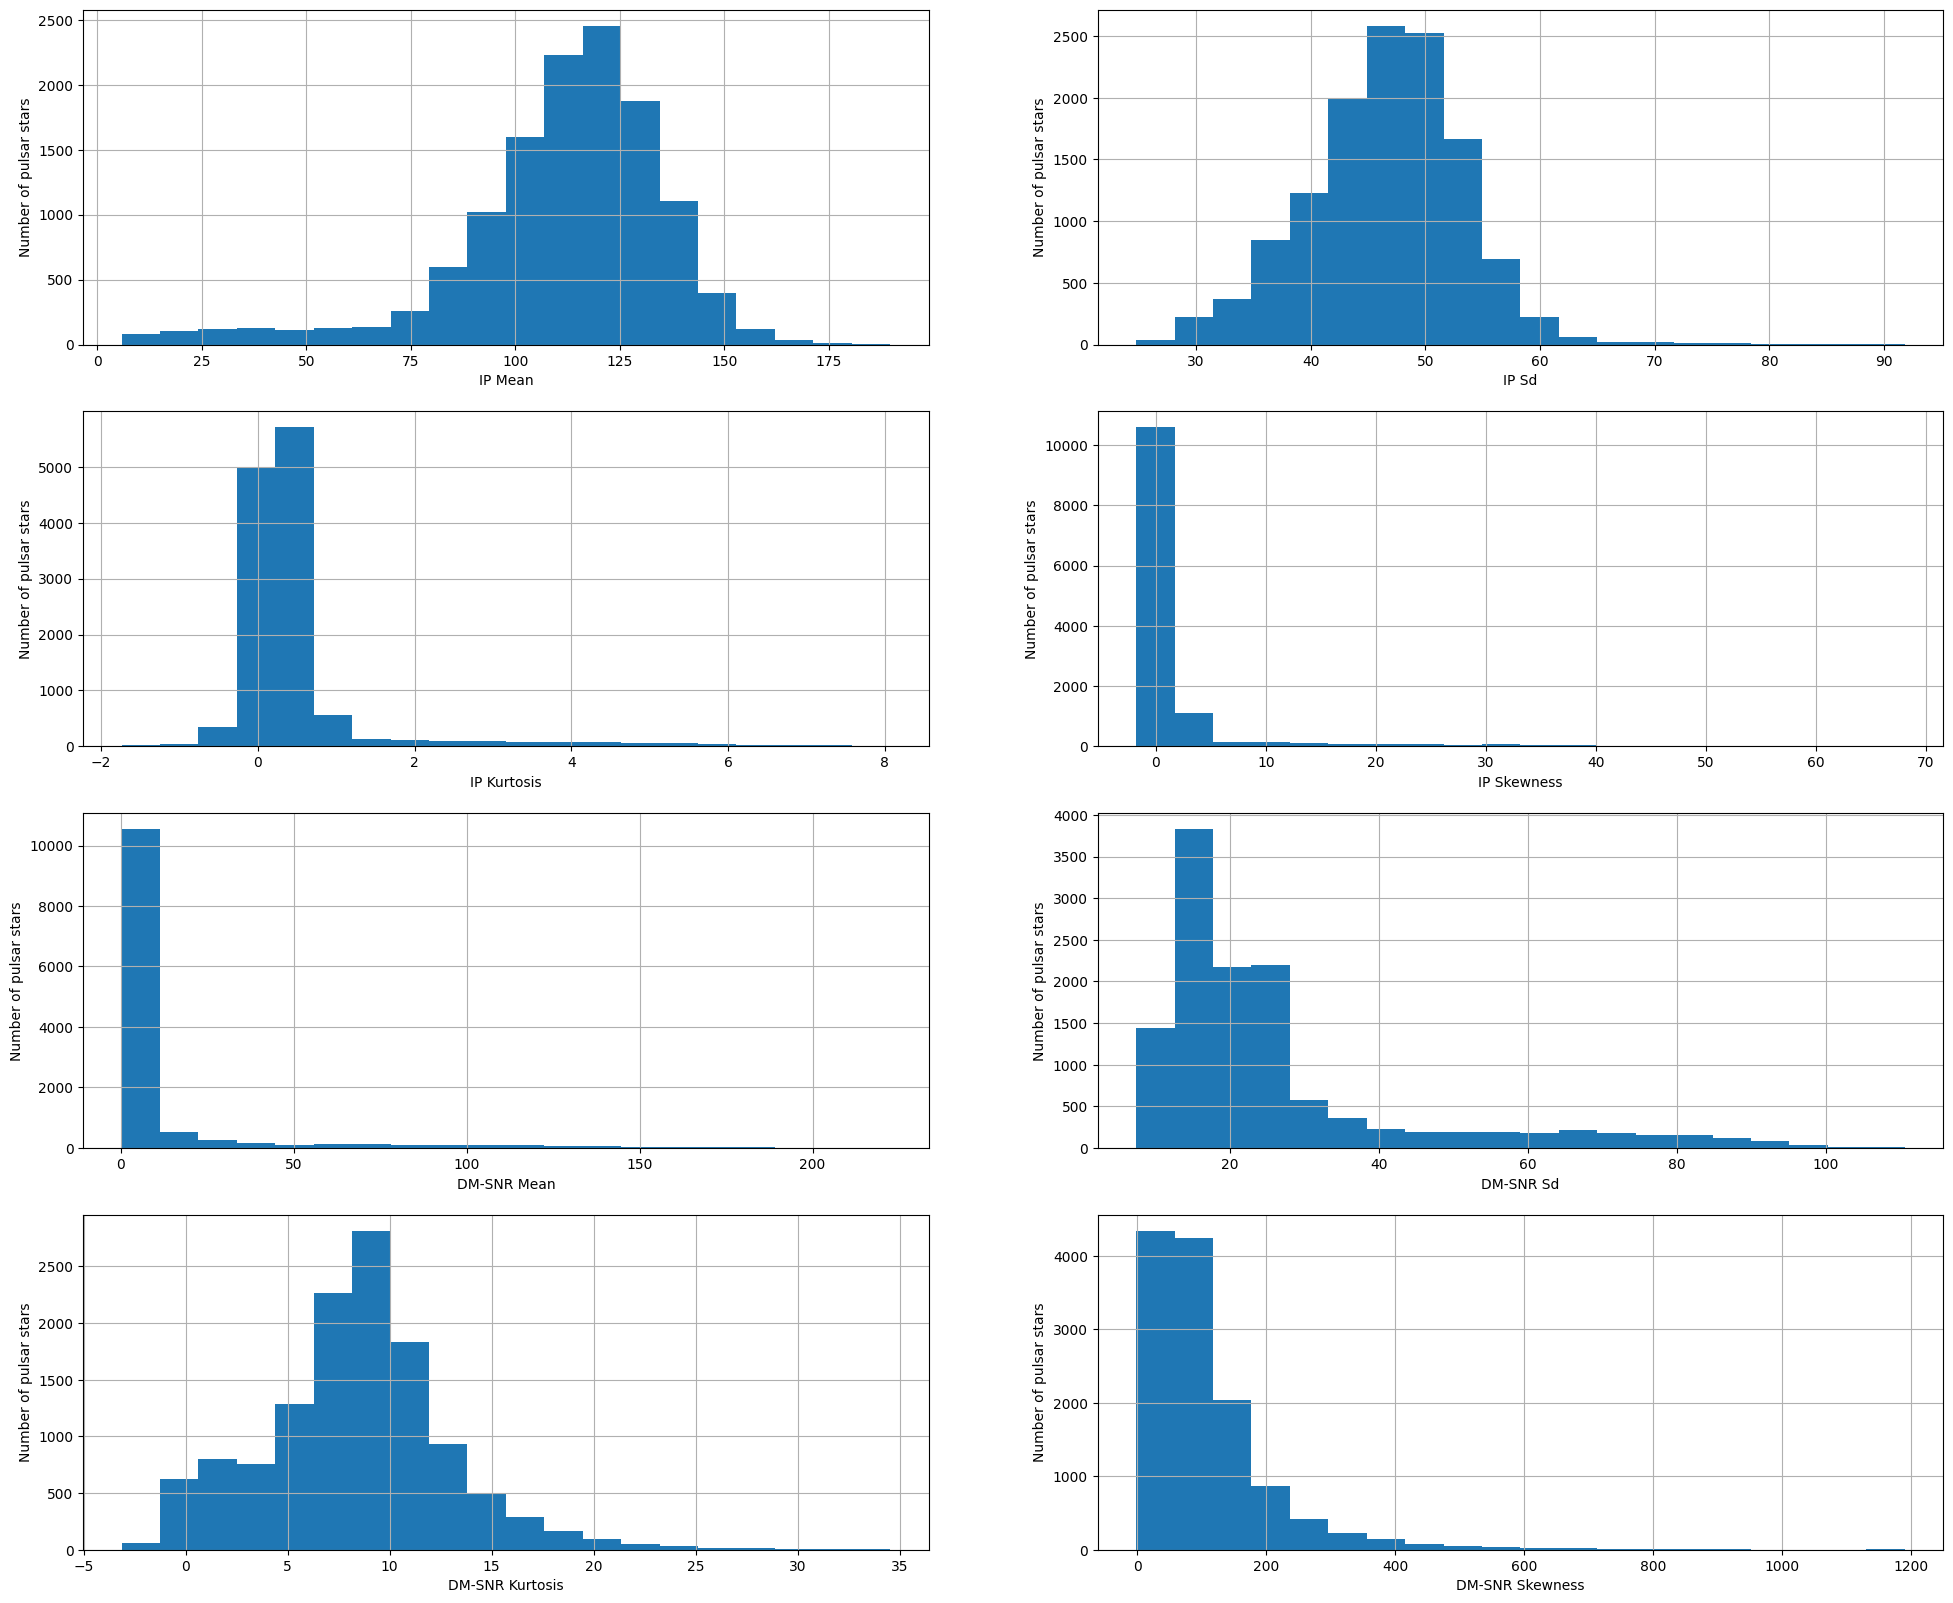

In [94]:
#Check the distribution of each columns

plt.figure(figsize = (24,20))

plt.subplot(4,2,1)
fig = df["IP Mean"].hist(bins = 20)
fig.set_xlabel("IP Mean")
fig.set_ylabel("Number of pulsar stars")

plt.subplot(4,2,2)
fig = df["IP Sd"].hist(bins = 20)
fig.set_xlabel("IP Sd")
fig.set_ylabel("Number of pulsar stars")

plt.subplot(4, 2, 3)
fig = df['IP Kurtosis'].hist(bins=20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 4)
fig = df['IP Skewness'].hist(bins=20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 5)
fig = df['DM-SNR Mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 6)
fig = df['DM-SNR Sd'].hist(bins=20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 7)
fig = df['DM-SNR Kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 8)
fig = df['DM-SNR Skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')

We can see that all the 8 continuous variables are skewed

In [95]:
X = df.drop("target_class", axis = 1)
y = df["target_class"]

In [96]:
#split X and y into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [97]:
X_train.shape, X_test.shape

((10022, 8), (2506, 8))

In [98]:
#Feature scaling

cols = X_train.columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [99]:
X_train = pd.DataFrame(X_train, columns = [cols])
X_train.describe()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness
count,1.002200e+04,1.002200e+04,1.002200e+04,1.002200e+04,1.002200e+04,1.002200e+04,1.002200e+04,1.002200e+04
mean,-5.530067e-17,-3.417298e-16,-9.074982e-17,4.750186e-17,1.276169e-17,-1.339978e-16,-3.438567e-16,9.783965e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-4.068339e+00,-3.134139e+00,-2.223380e+00,-5.727451e-01,-4.214866e-01,-1.021415e+00,-2.455262e+00,-1.021468e+00
25%,-3.959611e-01,-6.097959e-01,-4.255271e-01,-3.173982e-01,-3.643063e-01,-6.246641e-01,-5.566043e-01,-6.425814e-01
50%,1.596222e-01,6.301244e-02,-1.901037e-01,-2.550993e-01,-3.344944e-01,-3.613014e-01,2.694159e-02,-1.714147e-01
75%,6.302598e-01,6.596210e-01,-1.547561e-03,-1.375948e-01,-2.455011e-01,2.249242e-02,5.321119e-01,2.928110e-01
max,3.042041e+00,6.582758e+00,7.607455e+00,1.056901e+01,6.601589e+00,4.469061e+00,5.789238e+00,1.036577e+01


#### Run SVM with default hyperparameters

Default hyperparemeter means $C$ = 1.0, kernel = $\text{rbf}$, and $\text{gamma}$ = $\text{auto}$ among other parameters

In [100]:
X_train.info()
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10022 entries, 0 to 10021
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (IP Mean,)          10022 non-null  float64
 1   (IP Sd,)            10022 non-null  float64
 2   (IP Kurtosis,)      10022 non-null  float64
 3   (IP Skewness,)      10022 non-null  float64
 4   (DM-SNR Mean,)      10022 non-null  float64
 5   (DM-SNR Sd,)        10022 non-null  float64
 6   (DM-SNR Kurtosis,)  10022 non-null  float64
 7   (DM-SNR Skewness,)  10022 non-null  float64
dtypes: float64(8)
memory usage: 626.5 KB
<class 'pandas.core.series.Series'>
Index: 10022 entries, 2589 to 7270
Series name: target_class
Non-Null Count  Dtype  
--------------  -----  
10022 non-null  float64
dtypes: float64(1)
memory usage: 156.6 KB


In [110]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC(kernel = "rbf", C = 1.0)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9796488427773344


#### Run SVM with rbf kernel and C = 100.0

We have seen that there are outliers in our dataset. So, we should increase the value of $C$ as higher $C$ means fewer outliers. So, we will run SVM with kernel = $rbf$, and $C$ = 100.0.

In [111]:
svc = SVC(C = 100)

svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9776536312849162


In this case, we can see that the accuracy is decreased with $C$ = 100.0

#### Run SVM with linear kernel

Run SVM with linear kernel and $C$ = 1.0

In [112]:
linear_svc = SVC(kernel = 'linear', C = 1.0)

linear_svc.fit(X_train, y_train)

y_pred = linear_svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9776536312849162


Run SVM with linear kernel and $C$ = 100.0

In [113]:
linear_svc = SVC(kernel = 'linear', C = 100.0)

linear_svc.fit(X_train, y_train)

y_pred = linear_svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9780526735833999


Run SVM with linear kernel and C = 1000.0

In [115]:
linear_svc = SVC(kernel = "linear", C = 1000.0)

linear_svc.fit(X_train, y_train)

y_pred = linear_svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9780526735833999


We can see that the accuracy of model when using $C$ = 100.0 and $C$ = 1000.0 is higher than using $C$ = 1.0